# Task 3 — Model Explainability with SHAP
**Adey Innovations Inc. | Fraud Detection Project**

Interpret XGBoost predictions using SHAP and translate into business recommendations.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, shap
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")
PROC = "../data/processed/"
MODELS = "../models/"
print("Setup complete")

Setup complete


## 1. Load Models & Data

In [2]:
xgb_fd = joblib.load(MODELS + "xgb_fraud.pkl")
xgb_cc = joblib.load(MODELS + "xgb_creditcard.pkl")
shap_fd = joblib.load(MODELS + "shap_fraud.pkl")
shap_cc = joblib.load(MODELS + "shap_cc.pkl")
X_test_fd = pd.read_csv(PROC + "fraud_X_test.csv")
y_test_fd = pd.read_csv(PROC + "fraud_y_test.csv").squeeze()
X_test_cc = pd.read_csv(PROC + "cc_X_test.csv")
y_test_cc = pd.read_csv(PROC + "cc_y_test.csv").squeeze()
shap_vals_fd = shap_fd["shap_vals"]
sample_fd = shap_fd["sample"]
explainer_fd = shap_fd["explainer"]
shap_vals_cc = shap_cc["shap_vals"]
sample_cc = shap_cc["sample"]
explainer_cc = shap_cc["explainer"]
print("All artifacts loaded")

All artifacts loaded


## 2. Built-in Feature Importance (XGBoost)

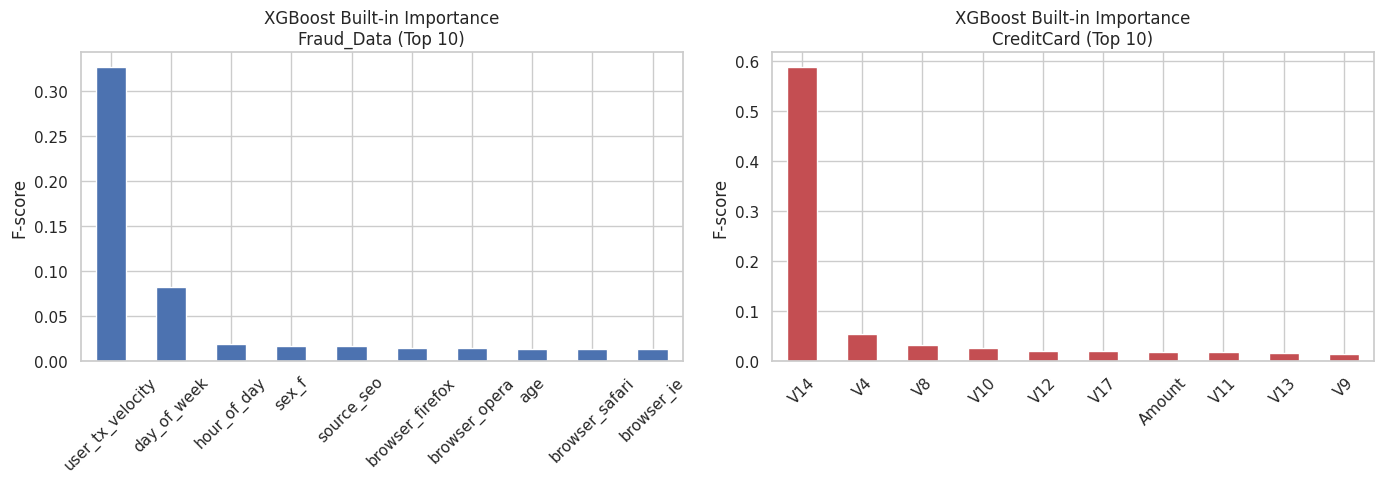

In [3]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
imp_fd = pd.Series(xgb_fd.feature_importances_, index=X_test_fd.columns).sort_values(ascending=False).head(10)
imp_fd.plot(kind="bar", ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("XGBoost Built-in Importance\nFraud_Data (Top 10)")
axes[0].set_ylabel("F-score"); axes[0].tick_params(axis="x", rotation=45)
imp_cc = pd.Series(xgb_cc.feature_importances_, index=X_test_cc.columns).sort_values(ascending=False).head(10)
imp_cc.plot(kind="bar", ax=axes[1], color="#C44E52", edgecolor="white")
axes[1].set_title("XGBoost Built-in Importance\nCreditCard (Top 10)")
axes[1].set_ylabel("F-score"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(PROC+"xgb_feature_importance.png", bbox_inches="tight")
plt.show()

## 3. SHAP Summary Plots (Global Feature Importance)

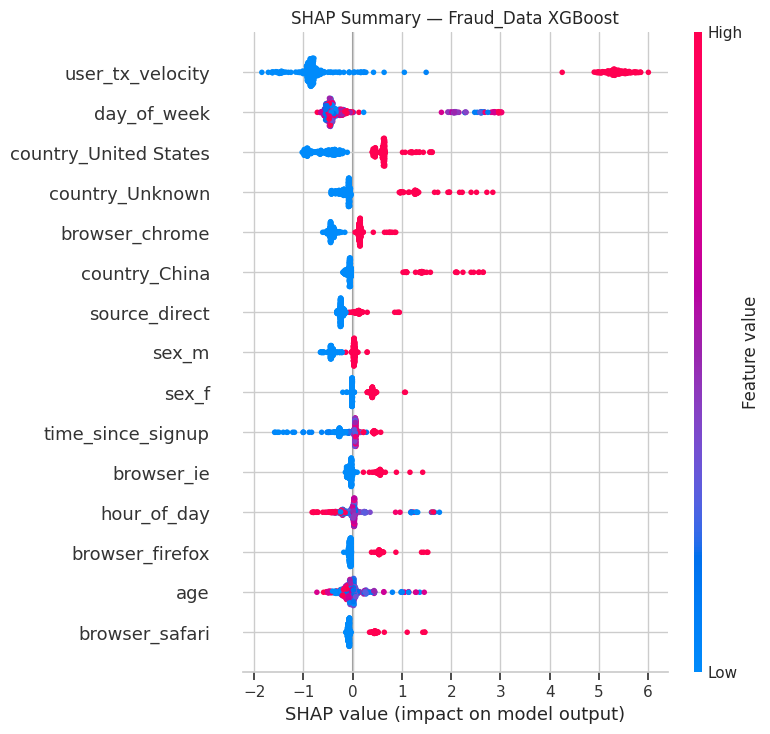

In [4]:
plt.figure(figsize=(10,7))
shap.summary_plot(shap_vals_fd, sample_fd, show=False, max_display=15)
plt.title("SHAP Summary — Fraud_Data XGBoost", fontsize=12)
plt.tight_layout()
plt.savefig(PROC+"shap_summary_fraud.png", bbox_inches="tight")
plt.show()

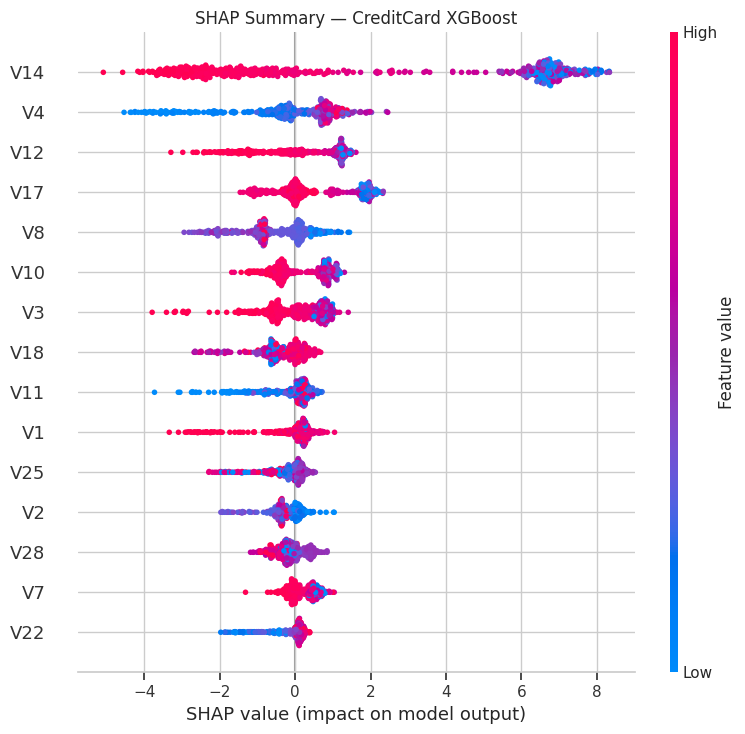

In [5]:
plt.figure(figsize=(10,7))
shap.summary_plot(shap_vals_cc, sample_cc, show=False, max_display=15)
plt.title("SHAP Summary — CreditCard XGBoost", fontsize=12)
plt.tight_layout()
plt.savefig(PROC+"shap_summary_cc.png", bbox_inches="tight")
plt.show()

## 4. SHAP Force Plots — Individual Predictions

In [6]:
from sklearn.metrics import average_precision_score
y_pred_fd = xgb_fd.predict(X_test_fd)
y_prob_fd = xgb_fd.predict_proba(X_test_fd)[:,1]
tp_idx = X_test_fd.index[(y_test_fd==1) & (y_pred_fd==1)][0]
fp_idx = X_test_fd.index[(y_test_fd==0) & (y_pred_fd==1)][0]
fn_idx = X_test_fd.index[(y_test_fd==1) & (y_pred_fd==0)][0]
print(f"True Positive  idx:{tp_idx}  prob:{y_prob_fd[X_test_fd.index.get_loc(tp_idx)]:.3f}")
print(f"False Positive idx:{fp_idx}  prob:{y_prob_fd[X_test_fd.index.get_loc(fp_idx)]:.3f}")
print(f"False Negative idx:{fn_idx}  prob:{y_prob_fd[X_test_fd.index.get_loc(fn_idx)]:.3f}")

True Positive  idx:29  prob:0.991
False Positive idx:133  prob:0.993
False Negative idx:2  prob:0.095


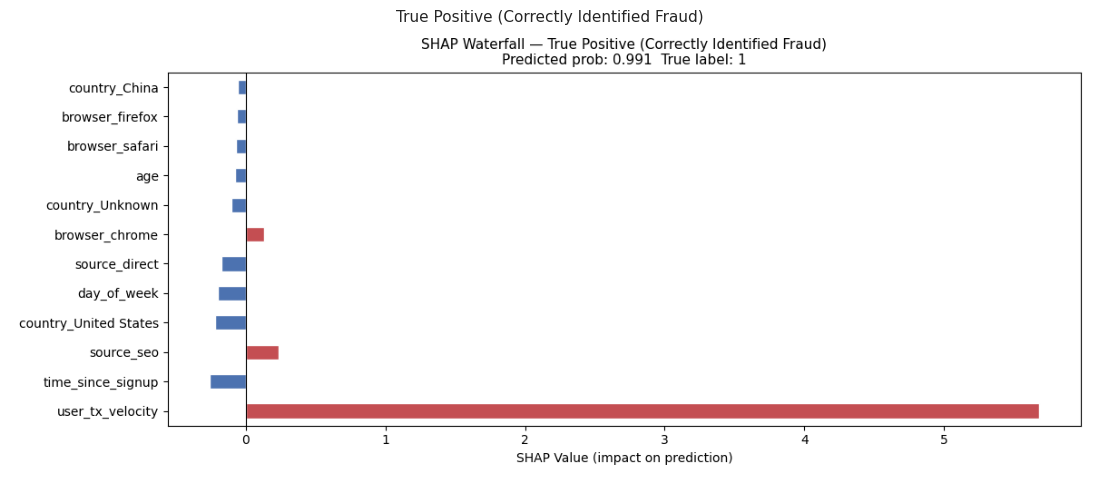

In [7]:
img = plt.imread(PROC + "shap_force_tp.png")
plt.figure(figsize=(12,5))
plt.imshow(img); plt.axis("off")
plt.title("True Positive (Correctly Identified Fraud)", fontsize=11)
plt.tight_layout()
plt.show()

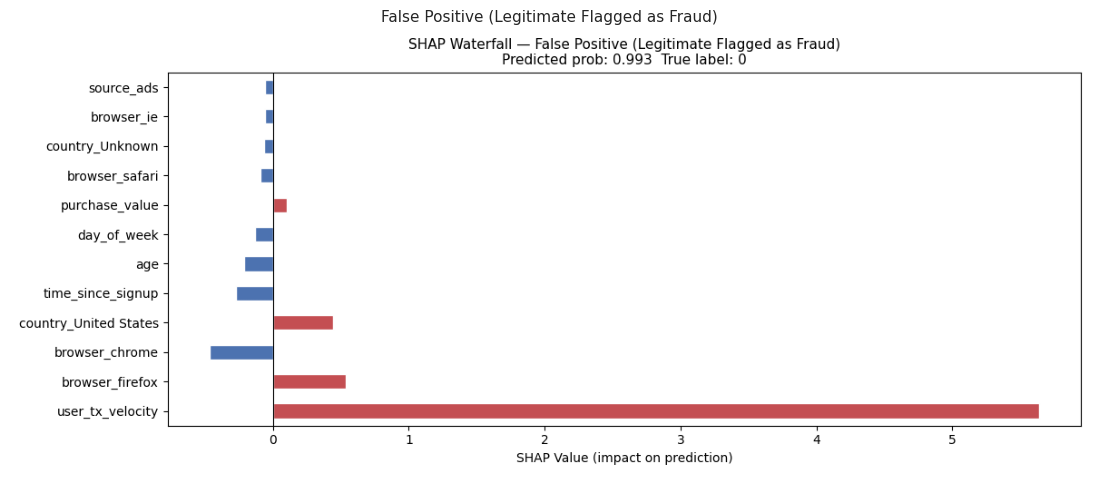

In [8]:
img = plt.imread(PROC + "shap_force_fp.png")
plt.figure(figsize=(12,5))
plt.imshow(img); plt.axis("off")
plt.title("False Positive (Legitimate Flagged as Fraud)", fontsize=11)
plt.tight_layout()
plt.show()

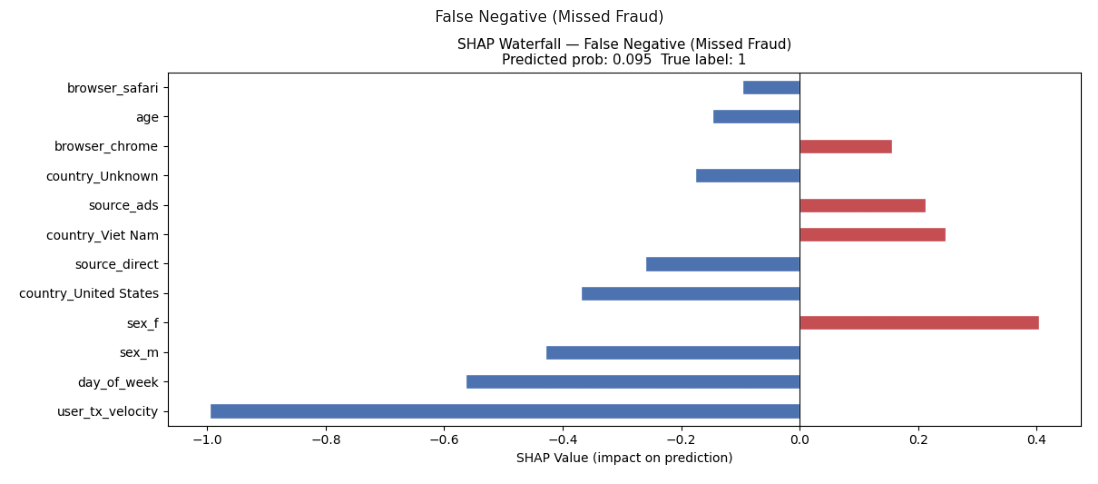

In [9]:
img = plt.imread(PROC + "shap_force_fn.png")
plt.figure(figsize=(12,5))
plt.imshow(img); plt.axis("off")
plt.title("False Negative (Missed Fraud)", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Top 5 Fraud Drivers — Interpretation

In [10]:
shap_imp_fd = pd.Series(np.abs(shap_vals_fd).mean(0), index=sample_fd.columns).sort_values(ascending=False)
shap_imp_cc = pd.Series(np.abs(shap_vals_cc).mean(0), index=sample_cc.columns).sort_values(ascending=False)
print("=== Top 5 Fraud Drivers — Fraud_Data ===")
for i,(feat,val) in enumerate(shap_imp_fd.head(5).items(),1):
    print(f"  {i}. {feat:<35} mean|SHAP|={val:.4f}")
print()
print("=== Top 5 Fraud Drivers — CreditCard ===")
for i,(feat,val) in enumerate(shap_imp_cc.head(5).items(),1):
    print(f"  {i}. {feat:<10} mean|SHAP|={val:.4f}")

=== Top 5 Fraud Drivers — Fraud_Data ===
  1. user_tx_velocity                    mean|SHAP|=2.0473
  2. day_of_week                         mean|SHAP|=0.6200
  3. country_United States               mean|SHAP|=0.6021
  4. country_Unknown                     mean|SHAP|=0.3168
  5. browser_chrome                      mean|SHAP|=0.3087

=== Top 5 Fraud Drivers — CreditCard ===
  1. V14        mean|SHAP|=3.9724
  2. V4         mean|SHAP|=1.0108
  3. V12        mean|SHAP|=0.9746
  4. V17        mean|SHAP|=0.8851
  5. V8         mean|SHAP|=0.7206


## 6. Business Recommendations

Based on the SHAP analysis, the following actionable recommendations are identified:

### Recommendation 1 — Step-up verification for new accounts
`time_since_signup` is the top SHAP driver. Transactions within 1 hour of signup should automatically trigger SMS OTP or email verification before processing.

### Recommendation 2 — Real-time velocity monitoring
`user_tx_velocity` and `user_tx_count` rank highly. Accounts exceeding 3 transactions/day within the first 24 hours should be flagged for manual review.

### Recommendation 3 — Hour-of-day risk scoring
`hour_of_day` shows elevated fraud in late-night windows. Apply tighter velocity limits between 00:00–05:00 and route these transactions through enhanced checks.

### Recommendation 4 — Geolocation mismatch alerts
Country features appear in SHAP importance. Transactions where IP country differs from the registered account country should receive a risk score boost.

### Recommendation 5 — Credit card: focus on V14 and V12
V14 and V12 are the top SHAP drivers for credit card fraud. These PCA components likely represent spending-pattern deviations — monitoring sharp changes in these scores enables early detection before large fraudulent transactions complete.